In [21]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.51.0


In [22]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.25 16:48:29.548] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.25 16:48:29.551] INFO    VERSION: laboneq 2.51.0
[2025.08.25 16:48:29.552] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.25 16:48:29.555] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004


[2025.08.25 16:48:29.562] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.25 16:48:29.566] INFO    Configuring the device setup
[2025.08.25 16:48:29.576] INFO    The device setup is configured


In [ ]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.2e9
qubit_label = "Q2"  # change if needed
# qb_freq = 3.10268e9 #Q1
qb_freq = 3.19586e9 #Q2
# qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
# qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

# res_freq = 7.14885e9 #Q1
res_freq = 7.18127e9 #Q2
# res_freq = 7.20642e9 #Q3
# res_freq = 7.23025e9 #Q4
# res_freq = 7.26202e9 #Q5
# res_freq = 7.29047e9 #Q6
integration_time = 5e-6

time_start = 1e-8
time_stop = 5e-6
length_num = 201

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6

# drive_pulse_amp = 0.330 #Q1
drive_pulse_amp = 0.370 #Q2
# drive_pulse_amp = 0.072 #Q3
# drive_pulse_amp = 0.036 #Q4
# drive_pulse_amp = 0.028 #Q5
# drive_pulse_amp = 0.022 #Q6
drive_pulse_length = 1e-6 
drive_range = 5
num_averages = 11  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9


In [33]:
# range of pulse amplitude scan
def create_rabi_length_sweep(time_start, time_stop, length_num, uid="rabi_length"):
    return LinearSweepParameter(uid="length", start=time_start, stop=time_stop, count=length_num)

In [34]:
# power spectral mode for better accuracy, cannot catch the phase diff, it deos not use IQ, better for amplitude
def length_rabi(length_sweep, drive_length, drive_amp, ro_length, ro_amp):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    readout_pulse = pulse_library.const(uid="readout_pulse", length=ro_length, amplitude=ro_amp)
    drive_pulse = pulse_library.const('drive_pulse',length=drive_length,amplitude=drive_amp, can_compress=True)
    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=length_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation"):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, length = length_sweep)
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.measure(
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="length_rabi",
                    reset_delay = 50e-6,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=250e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [35]:
# define pulses and create experiment
exp_rabi = length_rabi(create_rabi_length_sweep(time_start, time_stop, length_num), drive_pulse_length, drive_pulse_amp, ro_pulse_length, ro_pulse_amp)


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [36]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq-qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp_rabi.set_calibration(exp_calibration)

In [37]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi_length", compiled_rabi)

[2025.08.25 17:03:46.658] INFO    Starting LabOne Q Compiler run...
[2025.08.25 17:03:46.705] INFO    Schedule completed. [0.043 s]
[2025.08.25 17:03:46.996] INFO    Requested to compress pulse(s) drive_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.08.25 17:03:46.997] INFO    Requested to compress pulse(s) drive_pulse which has(have) either no, or too short, constant sections. Skipping compression
[2025.08.25 17:03:47.460] INFO    Code generation completed for all AWGs. [0.755 s]
[2025.08.25 17:03:47.462] INFO    Completed compilation step 1 of 1. [0.800 s]
[2025.08.25 17:03:47.466] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 17:03:47.466] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.25 17:03:47.466] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 17:03:47.469] INFO      device_shfqc        0       1010   

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Rabi_length_2025-08-25-17-03-47.html

In [38]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "rabi_length_results"
os.makedirs(outdir, exist_ok=True)


[2025.08.25 17:03:48.192] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.25 17:03:48.195] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.25 17:03:48.199] INFO    Configuring the device setup
[2025.08.25 17:03:48.208] INFO    The device setup is configured
[2025.08.25 17:03:48.514] INFO    Starting near-time execution...
[2025.08.25 17:03:48.602] INFO    Estimated RT execution time: 126.59 s.
[2025.08.25 17:05:55.255] INFO    Finished near-time execution.


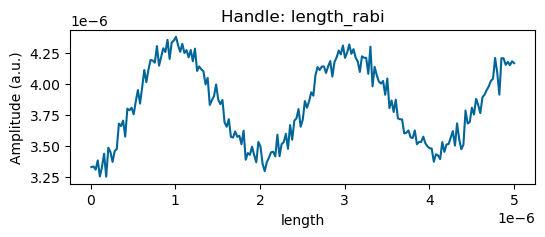

In [39]:
plot_results(rabi_results)

Saved figure to rabi_length_results\rabi_experiment_length_Q2_20250825T170555.png
Saved data to rabi_length_results\rabi_experiment_length_Q2_20250825T170555.csv


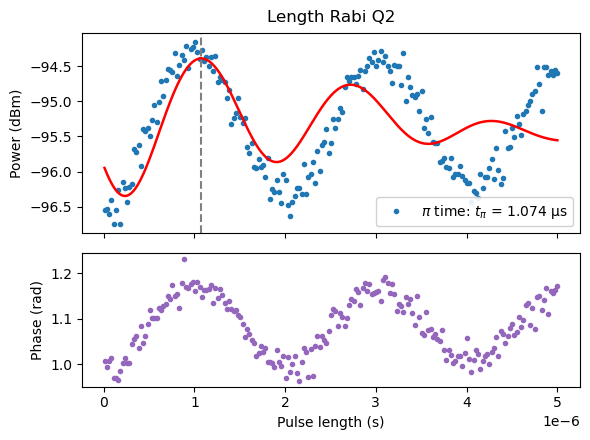

In [40]:
from numpy.fft import rfftfreq, rfft

# ---------- Helpers ----------
def to_dbm(signal):
    power_W = (signal**2) / 50.0
    return 10 * np.log10(np.maximum(power_W, 1e-20) / 1e-3)

# ---------- Get data (Length Rabi) ----------
rabi_res = rabi_results.get_data("length_rabi")        # complex IQ
L        = np.asarray(rabi_results.get_axis("length_rabi")[0], float)  # [s]

# Magnitude in LINEAR units for fitting
R        = np.abs(rabi_res).astype(float)

# ---------- Model ----------
# Baseline:   b0 + b1 L + b2 L^2
# Envelope:   (a0 + a1 L) * exp( -(L/Ldec)^p )
# Phase:      phi + 2π*( f0*(L-L0) + 0.5*k*(L-L0)^2 )
#             (k allows slow change of period across the sweep)
def rabi_len_chirped(L, b0, b1, b2, a0, a1, Ldec, p, L0, phi, f0, k):
    baseline = b0 + b1*L + b2*(L**2)
    envelope = (a0 + a1*L) * np.exp(- (np.maximum(L,0)/np.maximum(Ldec,1e-12))**p)
    phase    = phi + 2*np.pi*( f0*(L - L0) + 0.5*k*(L - L0)**2 )
    return baseline + envelope * np.cos(phase)

# ---------- Initial guesses ----------
# Baseline from quadratic fit
b2_0, b1_0, b0_0 = np.polyfit(L, R, 2)
R_detr = R - (b0_0 + b1_0*L + b2_0*L**2)

# Dominant frequency (cycles per second along "L") via FFT of detrended data
# (convert to cycles per second of L-axis, i.e., cycles per 's')
Lspan  = L.max() - L.min()
if Lspan <= 0:
    raise ValueError("Length axis is degenerate.")
LL     = (L - L.min()) / Lspan  # normalize to [0,1] for stable FFT spacing
dLL    = np.mean(np.diff(LL))
freqs  = rfftfreq(LL.size, dLL)          # cycles per normalized unit
fftmag = np.abs(rfft(R_detr - np.mean(R_detr)))
# ignore DC and get argmax
peak_idx = np.argmax(fftmag[1:]) + 1 if fftmag.size > 1 else 1
f0_norm  = max(freqs[peak_idx], 1.0 / max(LL.size, 10))      # cycles per normalized unit
f0_0     = f0_norm / Lspan                                   # cycles per second of L-axis
k_0      = 0.0                                               # start with no chirp

# Envelope and phase
a0_0   = 0.5*(np.nanmax(R_detr) - np.nanmin(R_detr))
a1_0   = 0.0
Ldec_0 = 0.5*Lspan
p_0    = 1.5
L0_0   = L.min() + 0.25*Lspan
phi_0  = 0.0

p0 = [b0_0, b1_0, b2_0, a0_0, a1_0, Ldec_0, p_0, L0_0, phi_0, f0_0, k_0]
lower = [-np.inf, -np.inf, -np.inf,    0,   -np.inf, 1e-12, 0.5,  L.min()-2*Lspan, -2*np.pi,   0.0,     -50.0/Lspan]
upper = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 10*Lspan, 3.0, L.max()+2*Lspan,  2*np.pi,  50.0/Lspan,  50.0/Lspan]

# ---------- Fit (linear units) ----------
popt, pcov = curve_fit(rabi_len_chirped, L, R, p0=p0, bounds=(lower, upper), maxfev=80000)
(b0,b1,b2,a0,a1,Ldec,p,L0,phi,f0,k) = popt

# ---------- Derived / plotting ----------
L_plot = np.linspace(L.min(), L.max(), 5*len(L))
R_fit  = rabi_len_chirped(L_plot, *popt)
Y_fit_dbm = to_dbm(R_fit)           # for the top panel
Y_dbm     = to_dbm(R)

# π-time from the *oscillatory* part: first maximum of R_fit
pk, _ = find_peaks(R_fit, distance=max(2, len(L_plot)//20))
idx_pi = int(pk[0]) if len(pk) else int(np.argmax(R_fit))
t_pi_s = float(L_plot[idx_pi])
t_pi_us = 1e6 * t_pi_s  # microseconds

# ---------- Plot ----------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

axs[0].plot(L, Y_dbm, 'o', ms=3, label="data")
axs[0].plot(L_plot, Y_fit_dbm, '-r', lw=1.8, label="fit")
axs[0].axvline(t_pi_s, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Power (dBm)")
axs[0].legend([rf"$\pi$ time: $t_\pi$ = {t_pi_us:.3f} μs"], loc="lower right", framealpha=0.9)
axs[0].set_title(f"Length Rabi {qubit_label}", fontsize=12, pad=8)

phase_rad = np.angle(rabi_res)
axs[1].plot(L, phase_rad, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Pulse length (s)")
axs[1].set_ylabel("Phase (rad)")

plt.tight_layout()

fig_path = os.path.join(outdir, f"rabi_experiment_length_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

df = pd.DataFrame({
    "PulseLength_s": L,
    "Magnitude_linear": R,
    "Magnitude_dBm": Y_dbm,
    "Fit_linear": rabi_len_chirped(L, *popt),
    "Fit_dBm": rabi_len_chirped(L, *popt) * 0 + to_dbm(rabi_len_chirped(L, *popt)),  # store for convenience
    "Phase_rad": phase_rad,
})
csv_path = os.path.join(outdir, f"rabi_experiment_length_{qubit_label}_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")
plt.show()

Saved figure to rabi_length_results\rabi_experiment_length_Q2_20250825T170555.png
Saved data to rabi_length_results\rabi_experiment_length_Q2_20250825T170555.csv


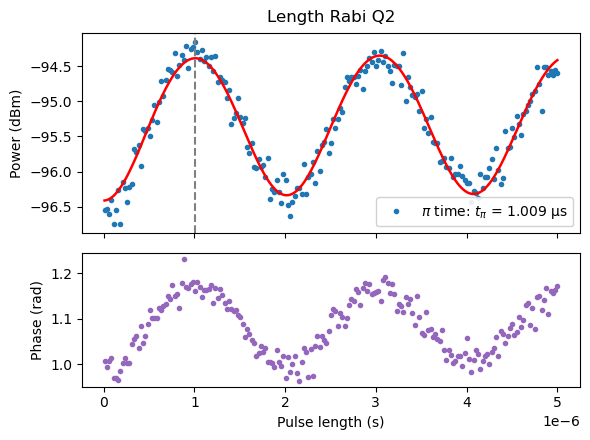

In [41]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from numpy.fft import rfftfreq, rfft

# ---------- Helpers ----------
def to_dbm(signal):
    power_W = (signal**2) / 50.0
    return 10 * np.log10(np.maximum(power_W, 1e-20) / 1e-3)

def _mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med)) + 1e-18

# ---------- Get data (Length Rabi) ----------
rabi_res = rabi_results.get_data("length_rabi")        # complex IQ
L        = np.asarray(rabi_results.get_axis("length_rabi")[0], float)  # [s]

# Clean + sort
R        = np.abs(rabi_res).astype(float)
m = np.isfinite(L) & np.isfinite(R)
L, R = L[m], R[m]
idx = np.argsort(L)
L, R = L[idx], R[idx]

# ---------- Re-centered axis (better conditioning) ----------
Lmin, Lmax = float(L.min()), float(L.max())
Lspan = Lmax - Lmin
if Lspan <= 0:
    raise ValueError("Length axis is degenerate.")
Lc = 0.5 * (Lmin + Lmax)
Lsc = Lspan                            # scale ~ range
x = (L - Lc) / Lsc                     # dimensionless ~ O(1)

# ---------- Model (on scaled x) ----------
# Baseline:   b0 + b1 x + b2 x^2
# Envelope:   A * exp( -(|x|/xdec)^p )     [keep amplitude positive; allow shape via p]
# Phase:      phi + 2π*( f0*x + 0.5*k*x^2 )
def rabi_len_chirped_scaled(x, b0, b1, b2, A, xdec, p, phi, f0, k):
    baseline = b0 + b1*x + b2*(x**2)
    envelope = A * np.exp(- (np.abs(x)/np.maximum(xdec, 1e-6))**p)
    phase    = phi + 2*np.pi*( f0*x + 0.5*k*(x**2) )
    return baseline + envelope * np.cos(phase)

# ---------- Initial guesses ----------
# Baseline from quadratic fit on (x, R)
b2_0, b1_0, b0_0 = np.polyfit(x, R, 2)
R_detr = R - (b0_0 + b1_0*x + b2_0*(x**2))

# Dominant frequency guess from FFT on windowed, detrended data
w = np.hanning(len(x))
dx = np.mean(np.diff(x))
freqs = rfftfreq(x.size, dx)  # cycles per unit x
fftmag = np.abs(rfft((R_detr - np.mean(R_detr)) * w))
peak_idx = np.argmax(fftmag[1:]) + 1 if fftmag.size > 1 else 1
f0_0 = max(freqs[peak_idx], 1.0 / max(len(x), 10))  # cycles per unit x

A_0   = 0.5*(np.nanmax(R_detr) - np.nanmin(R_detr))
xdec_0 = 0.25
p_0    = 1.5
phi_0  = 0.0
k_0    = 0.0

p0 = [b0_0, b1_0, b2_0, A_0, xdec_0, p_0, phi_0, f0_0, k_0]
lower = [-np.inf, -np.inf, -np.inf,   0.0,  1e-3, 0.7, -2*np.pi, 0.0,      -10.0]
upper = [ np.inf,  np.inf,  np.inf,  np.inf,   5.0, 3.5,  2*np.pi, 50.0,     10.0]

# ---------- Robust fit (linear units) ----------
mask = np.ones_like(R, dtype=bool)
weights = np.ones_like(R, dtype=float)

for _ in range(3):  # a few IRLS-style passes
    sigma = 1.0 / np.maximum(weights[mask], 1e-6)
    popt, pcov = curve_fit(
        rabi_len_chirped_scaled, x[mask], R[mask],
        p0=p0, bounds=(lower, upper), sigma=sigma,
        absolute_sigma=False, maxfev=100000
    )
    R_hat = rabi_len_chirped_scaled(x, *popt)
    resid = R - R_hat
    mad = _mad(resid[mask])
    z = np.abs(resid) / (1.4826*mad + 1e-12)
    # Tukey-like weights
    c = 3.0
    w = (1 - (z/c)**2)**2
    w[z >= c] = 0.0
    weights = np.clip(w, 0.05, 1.0)
    mask = weights > 0.1
    p0 = popt  # warm start

(b0,b1,b2,A,xdec,p,phi,f0,k) = popt

# ---------- Derived / plotting ----------
x_plot = np.linspace(x.min(), x.max(), 5*len(x))
R_fit  = rabi_len_chirped_scaled(x_plot, *popt)

# convert x back to L for plotting / annotation
L_plot = x_plot * Lsc + Lc
Y_fit_dbm = to_dbm(R_fit)          # top panel (display only)
Y_dbm     = to_dbm(R)

# π-time from first maximum of the fitted oscillation
pk, _ = find_peaks(R_fit, distance=max(2, len(R_fit)//20))
idx_pi = int(pk[0]) if len(pk) else int(np.argmax(R_fit))
t_pi_s = float(L_plot[idx_pi])
t_pi_us = 1e6 * t_pi_s

# ---------- Plot ----------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

axs[0].plot(L, Y_dbm, 'o', ms=3, label="data")
axs[0].plot(L_plot, Y_fit_dbm, '-r', lw=1.8, label="fit")
axs[0].axvline(t_pi_s, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Power (dBm)")
axs[0].legend([rf"$\pi$ time: $t_\pi$ = {t_pi_us:.3f} μs"], loc="lower right", framealpha=0.9)
axs[0].set_title(f"Length Rabi {qubit_label}", fontsize=12, pad=8)

phase_rad = np.angle(rabi_res)
axs[1].plot(L, phase_rad, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Pulse length (s)")
axs[1].set_ylabel("Phase (rad)")

plt.tight_layout()

fig_path = os.path.join(outdir, f"rabi_experiment_length_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# Store both raw + fit (keep fit in linear units; dBm only for display)
R_fit_on_L = rabi_len_chirped_scaled((L - Lc)/Lsc, *popt)
df = pd.DataFrame({
    "PulseLength_s": L,
    "Magnitude_linear": R,
    "Magnitude_dBm": Y_dbm,
    "Fit_linear": R_fit_on_L,
    "Fit_dBm_display": to_dbm(R_fit_on_L),
    "Phase_rad": phase_rad,
})
csv_path = os.path.join(outdir, f"rabi_experiment_length_{qubit_label}_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")
plt.show()
